Loading results...
Loading NYC dataset...

Visualizing UID: 541
Margin: 0.87
Full nDCG: 0.87
GPT2 nDCG: 0.00


C:\Users\ss348\AppData\Local\Temp\ipykernel_25900\4247706764.py:426: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


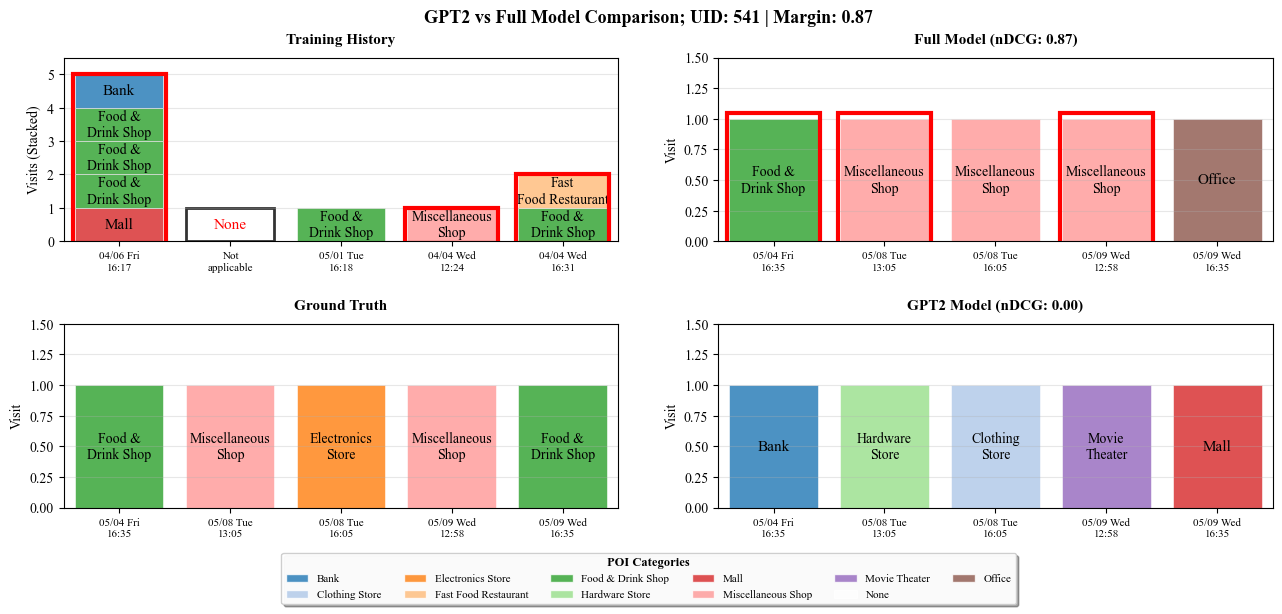

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import ast

# ═════════════════════════════════════════════════════════════════════
# SECTION 1: DATA LOADING AND PREPROCESSING
# ═════════════════════════════════════════════════════════════════════

def load_results(filepath='./past_results_pictures/result_September_17_new2.pkl'):
    """Load pickle results and convert to DataFrames."""
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    return pd.DataFrame(data['NYC']), pd.DataFrame(data['TKY'])


def load_and_filter_dataset(dataset_config):
    """Load parquet dataset and filter by minimum points."""
    df = pd.read_parquet(dataset_config['path'])
    
    # Filter users with minimum points
    counts = df["user_id"].value_counts()
    df_filtered = df[df["user_id"].map(counts) >= dataset_config['min_points']].copy()
    
    # Cap to first min_points per user
    df_filtered = df_filtered.sort_values(["user_id", "utc_time"], ascending=[True, True])
    df_filtered = df_filtered.groupby("user_id", group_keys=False).head(dataset_config['min_points'])
    
    return df_filtered[['user_id', 'category', 'lat', 'lon', 'utc_time']].reset_index(drop=True)


def per_user_last_split(df, user_col='user_id', time_col='utc_time', test_frac=0.2):
    """Split data per user based on temporal order."""
    train_dfs = []
    test_dfs = []
    
    for user_id, group in df.groupby(user_col):
        group = group.sort_values(time_col)
        n = len(group)
        split_idx = int(n * (1 - test_frac))
        train_dfs.append(group.iloc[:split_idx])
        test_dfs.append(group.iloc[split_idx:])
    
    return pd.concat(train_dfs, ignore_index=True), pd.concat(test_dfs, ignore_index=True)


def create_mappings(df):
    """Create user and item index mappings."""
    users = df['user_id'].unique()
    items = df['category'].unique()
    user2idx = {u: i for i, u in enumerate(users)}
    item2idx = {i: j for j, i in enumerate(items)}
    idx2item = {j: i for i, j in item2idx.items()}
    return user2idx, item2idx, idx2item


# ═════════════════════════════════════════════════════════════════════
# SECTION 2: UTILITY FUNCTIONS FOR ID MAPPING
# ═════════════════════════════════════════════════════════════════════

def _to_list(x):
    """Convert various types to list."""
    if x is None:
        return []
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return [x]
    return [x]


def map_ids_to_items(ids, idx2item):
    """Map item IDs to category names."""
    ids = _to_list(ids)
    out = []
    for i in ids:
        try:
            out.append(idx2item[int(i)])
        except Exception:
            out.append(f"UNK_{i}")
    return out


def map_ids_to_items_with_time(ids, idx2item, id2timeinfo):
    """Map IDs to categories with temporal information."""
    ids = _to_list(ids)
    out = []
    for i in ids:
        try:
            cat = idx2item[int(i)]
            ti = id2timeinfo.get(int(i), {})
            if ti:
                s = f"{cat} ({ti['month']:02d}-{ti['day']:02d} {ti['day_of_week'][:3]} {ti['time']})"
            else:
                s = cat
            out.append(s)
        except Exception:
            out.append(f"UNK_{i}")
    return out


# ═════════════════════════════════════════════════════════════════════
# SECTION 3: PREPARE DATA FOR VISUALIZATION
# ═════════════════════════════════════════════════════════════════════

def prepare_temporal_features(test_df):
    """Add temporal features and create time info lookup."""
    test_df['utc_time'] = pd.to_datetime(test_df['utc_time'])
    test_df['month'] = test_df['utc_time'].dt.month
    test_df['day'] = test_df['utc_time'].dt.day
    test_df['time'] = test_df['utc_time'].dt.strftime("%H:%M")
    test_df['day_of_week'] = test_df['utc_time'].dt.day_name()
    test_df['hour'] = test_df['utc_time'].dt.hour
    test_df['weekday'] = test_df['utc_time'].dt.dayofweek
    
    id2timeinfo = {
        i: {
            "category": row['category'],
            "month": row['month'],
            "day": row['day'],
            "time": row['time'],
            "day_of_week": row['day_of_week']
        }
        for i, row in test_df.reset_index().iterrows()
    }
    
    return id2timeinfo


def create_aligned_training_sequence(train_u, test_u):
    """Create training sequence aligned with test temporal patterns."""
    train_sequence = []
    
    for idx, test_row in test_u.iterrows():
        test_hour = test_row['hour']
        test_weekday = test_row['weekday']
        matching_train = train_u[
            (train_u['hour'] == test_hour) & 
            (train_u['weekday'] == test_weekday)
        ]
        
        if len(matching_train) > 0:
            for _, match in matching_train.iterrows():
                train_sequence.append({
                    'sequence_id': idx,
                    'category': match['category'],
                    'actual_date': match['utc_time'],
                    'test_time': test_row['utc_time'],
                    'count': 1,
                    'is_match': True
                })
        else:
            train_sequence.append({
                'sequence_id': idx,
                'category': 'None',
                'actual_date': None,
                'test_time': test_row['utc_time'],
                'count': 1,
                'is_match': False
            })
    
    return pd.DataFrame(train_sequence)


def prepare_prediction_data(df_out_row, test_u, pred_type='full'):
    """Prepare prediction data aligned with test sequence."""
    pred_key = 'full_pred_items' if pred_type == 'full' else 'GPT2_pred_items'
    pred_items = df_out_row[pred_key]
    
    pred_data = []
    for i in range(min(len(test_u), len(pred_items))):
        pred_data.append({
            'sequence_id': i,
            'category': pred_items[i],
            'time': test_u.iloc[i]['utc_time'],
            'count': 1
        })
    
    return pd.DataFrame(pred_data)


# ═════════════════════════════════════════════════════════════════════
# SECTION 4: TEXT FORMATTING FOR BARS
# ═════════════════════════════════════════════════════════════════════

def format_category_text(category):
    """
    Format category text for display in bars with word breaks.
    Handles slashes specially (e.g., 'Gas Station / Garage' -> 'Gas Station\n/\nGarage')
    """
    if '/' in category:
        # Split by slash and strip whitespace
        parts = [p.strip() for p in category.split('/')]
        return '/\n'.join(parts)
    
    # For long text without slashes, break at spaces
    words = category.split()
    if len(words) < 2:
        return category
    
    # Break into roughly equal parts
    mid = len(words) // 2
    return ' '.join(words[:mid]) + '\n' + ' '.join(words[mid:])


def create_x_labels_intuitive(time_series):
    """
    Create intuitive x-axis labels showing date and time.
    Format: Always show full date info for clarity
    "05/19 Sat\n00:59"
    """
    labels = []
    
    for dt in time_series:
        # Always show month/day weekday and time for clarity
        date_str = dt.strftime('%m/%d')
        weekday = dt.strftime('%a')
        time_str = dt.strftime('%H:%M')
        labels.append(f"{date_str} {weekday}\n{time_str}")
    
    return labels


# ═════════════════════════════════════════════════════════════════════
# SECTION 5: VISUALIZATION
# ═════════════════════════════════════════════════════════════════════

def normalize_categories(dataframes):
    """Normalize category names across all dataframes."""
    replacements = {
        'Gym / Fitness Center': 'Gym',
        'Dim Sum Restaurant': 'Dim-sum Restaurant'
    }
    
    for df in dataframes:
        if not df.empty and 'category' in df.columns:
            df['category'] = df['category'].replace(replacements)


def wrap_legend_labels(labels, max_chars=22):
    """Wrap long legend labels."""
    wrapped = []
    for label in labels:
        if len(label) > max_chars:
            mid = len(label) // 2
            break_chars = [' ', '-', '_']
            best_break = mid
            for char in break_chars:
                for i in range(mid-5, mid+6):
                    if i < len(label) and label[i] == char:
                        best_break = i + 1
                        break
                if best_break != mid:
                    break
            wrapped.append(label[:best_break] + '\n' + label[best_break:])
        else:
            wrapped.append(label)
    return wrapped


def plot_comparison(train_visits, test_visits, full_visits, gpt2_visits, 
                   row_out, target_uid, palette, save_path=None):
    """Create 2x2 comparison plot."""
    
    fig = plt.figure(figsize=(13, 6))
    gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.18,
                          left=0.05, right=0.98, top=0.9, bottom=0.15)
    
    # Calculate training match count
    training_match_count = 0
    if not train_visits.empty and not test_visits.empty:
        train_sets = train_visits.groupby('sequence_id')['category'].apply(set)
        for i in range(len(test_visits)):
            if i in train_sets and test_visits.iloc[i]['category'] in train_sets.loc[i]:
                training_match_count += 1
    
    # Title
    fig.suptitle(
        f"GPT2 vs Full Model Comparison; UID: {target_uid} | Margin: {row_out['margin']:.2f}",
        # f"Training Contains GT: {training_match_count}/{len(test_visits)}",
        fontsize=13, fontweight='bold', y=0.98
    )
    
    # Create axes
    ax_train = fig.add_subplot(gs[0, 0])
    ax_test = fig.add_subplot(gs[1, 0])
    ax_full = fig.add_subplot(gs[0, 1])
    ax_gpt2 = fig.add_subplot(gs[1, 1])
    
    axes = [ax_train, ax_test, ax_full, ax_gpt2]
    datasets = [
        ("Training History", train_visits, None),
        ("Ground Truth", test_visits, None),
        (f"Full Model (nDCG: {row_out['full_nDCG']:.2f})", full_visits, test_visits),
        (f"GPT2 Model (nDCG: {row_out['GPT2_nDCG']:.2f})", gpt2_visits, test_visits)
    ]
    
    for idx, (ax, (title, df_plot, df_gt)) in enumerate(zip(axes, datasets)):
        if df_plot.empty:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center",
                    fontsize=12, transform=ax.transAxes)
            ax.set_title(title, fontweight='bold', fontsize=11)
            continue
        
        if idx == 0:  # Training (stacked bars)
            unique_seq_ids = sorted(df_plot['sequence_id'].unique())
            max_stack_height = df_plot.groupby('sequence_id').size().max()
            
            for seq_id in unique_seq_ids:
                seq_data = df_plot[df_plot['sequence_id'] == seq_id].reset_index(drop=True)
                bottom = 0
                
                for _, row in seq_data.iterrows():
                    color = palette[row['category']]
                    edgecolor = 'black' if row['category'] == 'None' else 'white'
                    linewidth = 2 if row['category'] == 'None' else 0.5
                    
                    ax.bar(seq_id, 1, bottom=bottom, color=color, width=0.8, alpha=0.8,
                           edgecolor=edgecolor, linewidth=linewidth)
                    
                    # Category label - ALWAYS HORIZONTAL with word breaks
                    label_text = format_category_text(row['category'])
                    text_color = 'red' if row['category'] == 'None' else 'black'
                    fontsize = 10 if '\n' in label_text else 11
                    
                    ax.text(seq_id, bottom + 0.5, label_text, ha='center', va='center',
                            fontsize=fontsize, color=text_color, rotation=0)
                    bottom += 1
                
                # Highlight if GT category exists in training
                if seq_id < len(test_visits):
                    gt_cat = test_visits.iloc[seq_id]['category']
                    if gt_cat in set(seq_data['category']):
                        rect = Rectangle((seq_id - 0.42, -0.05), 0.84, bottom + 0.05,
                                       linewidth=3, edgecolor='red', facecolor='none', zorder=10)
                        ax.add_patch(rect)
            
            ax.set_ylim(0, max_stack_height + 0.5)
            ax.set_ylabel("Visits (Stacked)", fontsize=10)
            
            # X-axis labels for training - use actual_date when available
            if 'actual_date' in df_plot.columns:
                # For training, show the actual training timestamps, or "Not applicable" for None
                time_labels = []
                for seq_id in unique_seq_ids:
                    seq_data = df_plot[df_plot['sequence_id'] == seq_id]
                    # Check if this sequence only contains "None" category
                    if set(seq_data['category']) == {'None'}:
                        time_labels.append("Not\napplicable")
                    else:
                        # Get first match with actual date
                        matches = seq_data[seq_data['is_match'] == True]
                        if len(matches) > 0 and pd.notna(matches.iloc[0]['actual_date']):
                            dt = matches.iloc[0]['actual_date']
                            date_str = dt.strftime('%m/%d')
                            weekday = dt.strftime('%a')
                            time_str = dt.strftime('%H:%M')
                            time_labels.append(f"{date_str} {weekday}\n{time_str}")
                        else:
                            time_labels.append("Not\napplicable")
                
                ax.set_xticks(unique_seq_ids)
                ax.set_xticklabels(time_labels, fontsize=8, rotation=0)
        
        else:  # Single bars for test/predictions
            time_col = 'time' if 'time' in df_plot.columns else 'test_time'
            colors = [palette[cat] for cat in df_plot['category']]
            ax.bar(df_plot['sequence_id'], df_plot['count'], color=colors, 
                   width=0.8, alpha=0.8, edgecolor='white', linewidth=0.5)
            
            # Highlight correct predictions
            if df_gt is not None:
                for seq_id, category in zip(df_plot['sequence_id'], df_plot['category']):
                    if seq_id < len(df_gt) and category == df_gt.iloc[seq_id]['category']:
                        rect = Rectangle((seq_id - 0.42, -0.05), 0.84, 1.1,
                                       linewidth=3, edgecolor='red', facecolor='none', zorder=10)
                        ax.add_patch(rect)
            
            # Category labels on bars - ALWAYS HORIZONTAL with word breaks
            for seq_id, category in zip(df_plot['sequence_id'], df_plot['category']):
                label_text = format_category_text(category)
                fontsize = 10 if '\n' in label_text else 11
                
                ax.text(seq_id, 0.5, label_text, ha='center', va='center',
                       fontsize=fontsize, color='black', rotation=0)
            
            ax.set_ylim(0, 1.5)
            ax.set_ylabel("Visit", fontsize=10)
            
            # X-axis labels - intuitive format
            time_labels = create_x_labels_intuitive(df_plot[time_col])
            ax.set_xticks(df_plot['sequence_id'])
            ax.set_xticklabels(time_labels, fontsize=8, rotation=0)
        
        ax.set_title(title, fontweight='bold', pad=10, fontsize=11)
        ax.grid(True, axis='y', alpha=0.3)
        ax.set_xlim(-0.5, len(df_plot['sequence_id'].unique()) - 0.5)
    
    # Legend (2 rows)
    all_pois = sorted(palette.keys())
    legend_elements = [Rectangle((0,0),1,1, facecolor=palette[poi], alpha=0.8, edgecolor='white')
                      for poi in all_pois]
    wrapped_labels = wrap_legend_labels(all_pois, max_chars=25)
    
    # Calculate ncol to make roughly 2 rows
    n_items = len(all_pois)
    ncol = max(5, (n_items + 1) // 2)
    
    legend = fig.legend(
        legend_elements, wrapped_labels, title="POI Categories",
        loc='lower center', bbox_to_anchor=(0.5, -0.02),
        ncol=ncol, frameon=True, 
        fancybox=True, shadow=True, fontsize=8
    )
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.95)
    legend.get_title().set_fontweight('bold')
    legend.get_title().set_fontsize(9)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


# ═════════════════════════════════════════════════════════════════════
# SECTION 6: MAIN EXECUTION
# ═════════════════════════════════════════════════════════════════════

def main():
    # Configuration
    DATASET_CONFIG = {
        'name': 'NYC',
        'path': './data/TSMC2014_nyc.parquet',
        'min_points': 50,
        'test_frac': 0.2
    }
    plt.rcParams['font.family'] = "Times New Roman"
    # Load results
    print("Loading results...")
    nyc, tky = load_results()
    
    # Load and prepare dataset
    print(f"Loading {DATASET_CONFIG['name']} dataset...")
    df = load_and_filter_dataset(DATASET_CONFIG)
    
    # Create mappings
    user2idx, item2idx, idx2item = create_mappings(df)
    
    # Split data
    train_df, test_df = per_user_last_split(df, test_frac=DATASET_CONFIG['test_frac'])
    train_df.rename(columns={'user_id': 'uid'}, inplace=True)
    test_df.rename(columns={'user_id': 'uid'}, inplace=True)
    
    # Prepare temporal features
    id2timeinfo = prepare_temporal_features(test_df)
    prepare_temporal_features(train_df)
    
    # Analyze results - filter K=5 and calculate margins
    nyc_k5 = nyc[nyc.K == 5].copy()
    nyc_k5['margin'] = nyc_k5["full_nDCG"].astype(float) - nyc_k5['GPT2_nDCG'].astype(float)
    top_margins = nyc_k5[nyc_k5['margin'] > 0].sort_values('margin', ascending=False)
    
    # Build output dataframe
    rows = []
    for _, r in top_margins.iterrows():
        uid = r.get('uid', r.get('user_id'))
        truth_ids = r.get('true_seq', r.get('truth', []))
        full_pred_ids = r.get('full_pred', [])
        gpt2_ids = r.get('GPT2_pred', [])
        
        rows.append({
            'uid': uid,
            'K': r.get('K'),
            'margin': float(r['margin']),
            'GPT2_nDCG': float(r.get('GPT2_nDCG', np.nan)),
            'full_nDCG': float(r.get("full_nDCG", np.nan)),
            'truth_items': map_ids_to_items_with_time(truth_ids, idx2item, id2timeinfo),
            'GPT2_pred_items': map_ids_to_items(gpt2_ids, idx2item),
            'full_pred_items': map_ids_to_items(full_pred_ids, idx2item)
        })
    
    df_out = pd.DataFrame(rows)
    
    # Select example (change index as needed)
    example_idx = 7
    target_uid = df_out.iloc[5]['uid']
    # print(df_out)
    row_out = df_out[df_out['uid'] == target_uid].iloc[0]
    
    print(f"\nVisualizing UID: {target_uid}")
    print(f"Margin: {row_out['margin']:.2f}")
    print(f"Full nDCG: {row_out['full_nDCG']:.2f}")
    print(f"GPT2 nDCG: {row_out['GPT2_nDCG']:.2f}")
    
    # Prepare user-specific data
    train_u = train_df[train_df['uid'] == target_uid].sort_values('utc_time').reset_index(drop=True)
    test_u = test_df[test_df['uid'] == target_uid].sort_values('utc_time').reset_index(drop=True)
    test_u = test_u.iloc[:5]  # Limit to K=5
    
    # Create aligned sequences
    train_visits = create_aligned_training_sequence(train_u, test_u)
    
    test_visits = pd.DataFrame([{
        'sequence_id': idx,
        'category': row['category'],
        'time': row['utc_time'],
        'count': 1
    } for idx, row in test_u.iterrows()])
    
    full_visits = prepare_prediction_data(row_out, test_u, 'full')
    gpt2_visits = prepare_prediction_data(row_out, test_u, 'gpt2')
    
    # Normalize categories
    normalize_categories([train_visits, test_visits, full_visits, gpt2_visits])
    
    # Create color palette
    all_pois = set()
    for df in [train_visits, test_visits, full_visits, gpt2_visits]:
        if not df.empty:
            all_pois.update(df['category'].unique())
    palette = dict(zip(sorted(all_pois), sns.color_palette("tab20", len(all_pois))))
    palette['None'] = 'white'
    
    # Create visualization
    plot_comparison(train_visits, test_visits, full_visits, gpt2_visits,
                   row_out, target_uid, palette, 
                   save_path=f"GPT2_uid_{target_uid}_improved.png")


if __name__ == "__main__":
    main()